# 🚗 Traffic Accident Severity Prediction: ML for Road Safety Policy

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Predicting accident severity to support road safety investment and emergency response optimisation  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for predicting traffic accident severity (slight/serious/fatal) based on road conditions, weather, vehicle type, and driver characteristics. The model supports **evidence-based road safety policy** and **emergency response triage**.

### Government Policy Context
- **BITRE (Bureau of Infrastructure & Transport Research Economics)** — Road safety statistics, cost-benefit analysis of safety interventions
- **Department of Infrastructure, Transport** — National Road Safety Strategy 2021-2030, Vision Zero targets
- **State Road Authorities** — VicRoads, Transport for NSW, Main Roads WA — black spot identification, speed limit reviews
- **ANCAP / ACRS** — Vehicle safety ratings, road safety research
- **Emergency Services** — Pre-hospital triage, resource allocation, helicopter dispatch thresholds

### Operational Decision Framework
| Predicted Severity | Action | Stakeholder |
|-----------|--------|-------------|
| Fatal / Serious (high conf) | Dispatch helicopter + multiple units, trauma surgeon alert | Emergency ops |
| Serious (moderate conf) | Enhanced first response, hospital pre-alert | Ambulance dispatch |
| Slight (confident) | Standard response, routine processing | Police + ambulance |
| Any (post-incident) | Update black spot register, review speed limits | Road authority |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, cohen_kappa_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)


ENVIRONMENT READY


In [2]:
data_path = None
print("Scanning /kaggle/input...")
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv'):
            data_path = full_path
if data_path is None:
    raise FileNotFoundError("No CSV found")
with open(data_path, 'r') as fh:
    sample = fh.read(2048)
sep = ';' if sample.count(';') > sample.count(',') else ','
df = pd.read_csv(data_path, sep=sep)
print(f"\nLoaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


Scanning /kaggle/input...
  Found: /kaggle/input/datasets/avikumart/road-traffic-severity-classification/RTA Dataset.csv

Loaded: 12,316 rows x 32 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    null_pct = f" ({nulls/len(df)*100:.1f}%)" if nulls > 0 else ""
    sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f"  {i:2d}. {col:35s} | {str(dtype):10s} | unique={nuniq:5d} | nulls={nulls}{null_pct}")
df.head()


COLUMN SUMMARY
   0. Time                                | object     | unique= 1074 | nulls=0
   1. Day_of_week                         | object     | unique=    7 | nulls=0
   2. Age_band_of_driver                  | object     | unique=    5 | nulls=0
   3. Sex_of_driver                       | object     | unique=    3 | nulls=0
   4. Educational_level                   | object     | unique=    7 | nulls=741 (6.0%)
   5. Vehicle_driver_relation             | object     | unique=    4 | nulls=579 (4.7%)
   6. Driving_experience                  | object     | unique=    7 | nulls=829 (6.7%)
   7. Type_of_vehicle                     | object     | unique=   17 | nulls=950 (7.7%)
   8. Owner_of_vehicle                    | object     | unique=    4 | nulls=482 (3.9%)
   9. Service_year_of_vehicle             | object     | unique=    6 | nulls=3928 (31.9%)
  10. Defect_of_vehicle                   | object     | unique=    3 | nulls=4427 (35.9%)
  11. Area_accident_occured           

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


## 2. Target Variable Identification & Analysis

In [4]:
target_candidates = ['Accident_severity', 'accident_severity', 'Severity', 'severity',
                     'Accident Severity', 'Target', 'target', 'Class', 'class',
                     'Injury_Severity', 'SEVERITY']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    for col in df.columns:
        if df[col].dtype == 'object' and df[col].nunique() <= 10:
            vals = [str(v).lower() for v in df[col].unique()]
            severity_kw = ['slight', 'serious', 'fatal', 'minor', 'major', 'injury']
            if any(kw in v for v in vals for kw in severity_kw):
                target_col = col
                print(f"Auto-detected: '{target_col}'")
                break

if target_col is None:
    last_col = df.columns[-1]
    if df[last_col].nunique() <= 10:
        target_col = last_col
        print(f"Fallback: '{target_col}'")

if target_col is None:
    raise ValueError("Could not identify target")

print(f"\nRaw values:")
print(df[target_col].value_counts())

if df[target_col].dtype == 'object':
    le_target = LabelEncoder()
    df[target_col] = le_target.fit_transform(df[target_col])
    target_labels = list(le_target.classes_)
    print(f"\nEncoded: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")
else:
    target_labels = [str(x) for x in sorted(df[target_col].unique())]

print(f"\nDistribution:")
print(df[target_col].value_counts().sort_index())
assert df[target_col].nunique() >= 2


Found target: 'Accident_severity'

Raw values:
Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64

Encoded: {'Fatal injury': np.int64(0), 'Serious Injury': np.int64(1), 'Slight Injury': np.int64(2)}

Distribution:
Accident_severity
0      158
1     1743
2    10415
Name: count, dtype: int64


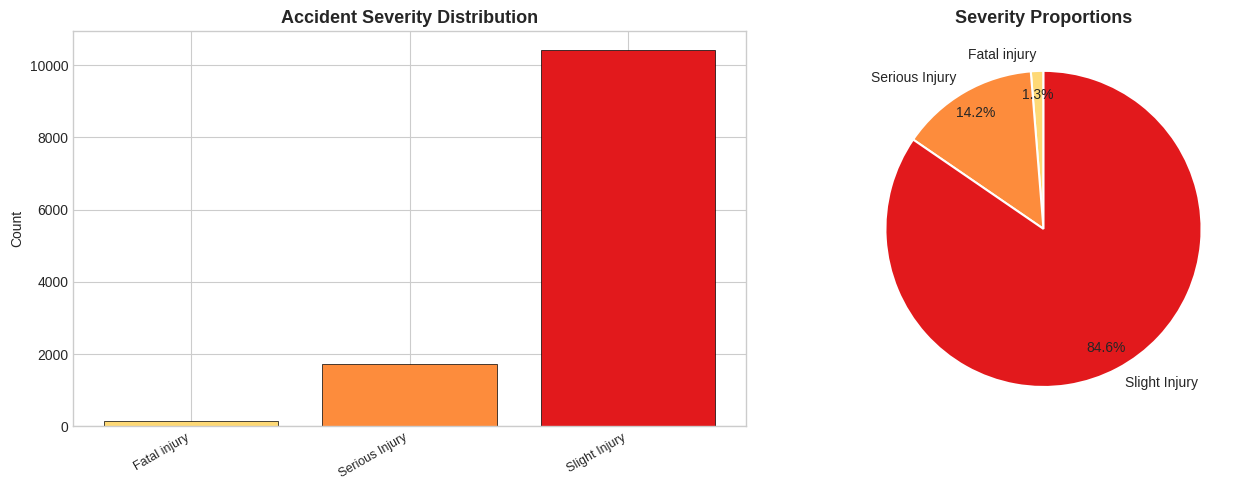

Australian context: ~1,200 road deaths p.a. (BITRE). National target: zero fatalities by 2050.
Each fatal crash costs ~$8.4M, serious injury ~$430K (BITRE crash cost estimates).


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df[target_col].value_counts().sort_index()
n_classes = len(vc)
colors = sns.color_palette('YlOrRd', n_colors=n_classes)
labels = target_labels if len(target_labels) == n_classes else [f'Class {x}' for x in vc.index]

axes[0].bar(range(n_classes), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(n_classes))
axes[0].set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
axes[0].set_title('Accident Severity Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Severity Proportions', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("Australian context: ~1,200 road deaths p.a. (BITRE). National target: zero fatalities by 2050.")
print("Each fatal crash costs ~$8.4M, serious injury ~$430K (BITRE crash cost estimates).")


## 3. Exploratory Data Analysis

Key questions for road safety policy:
- Which road/weather conditions correlate with severe accidents?
- Do certain vehicle types or driver demographics have higher severity?
- Are there temporal patterns (time of day, day of week)?
- Which factors are most actionable for policy intervention?


Categorical features (26): ['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle']


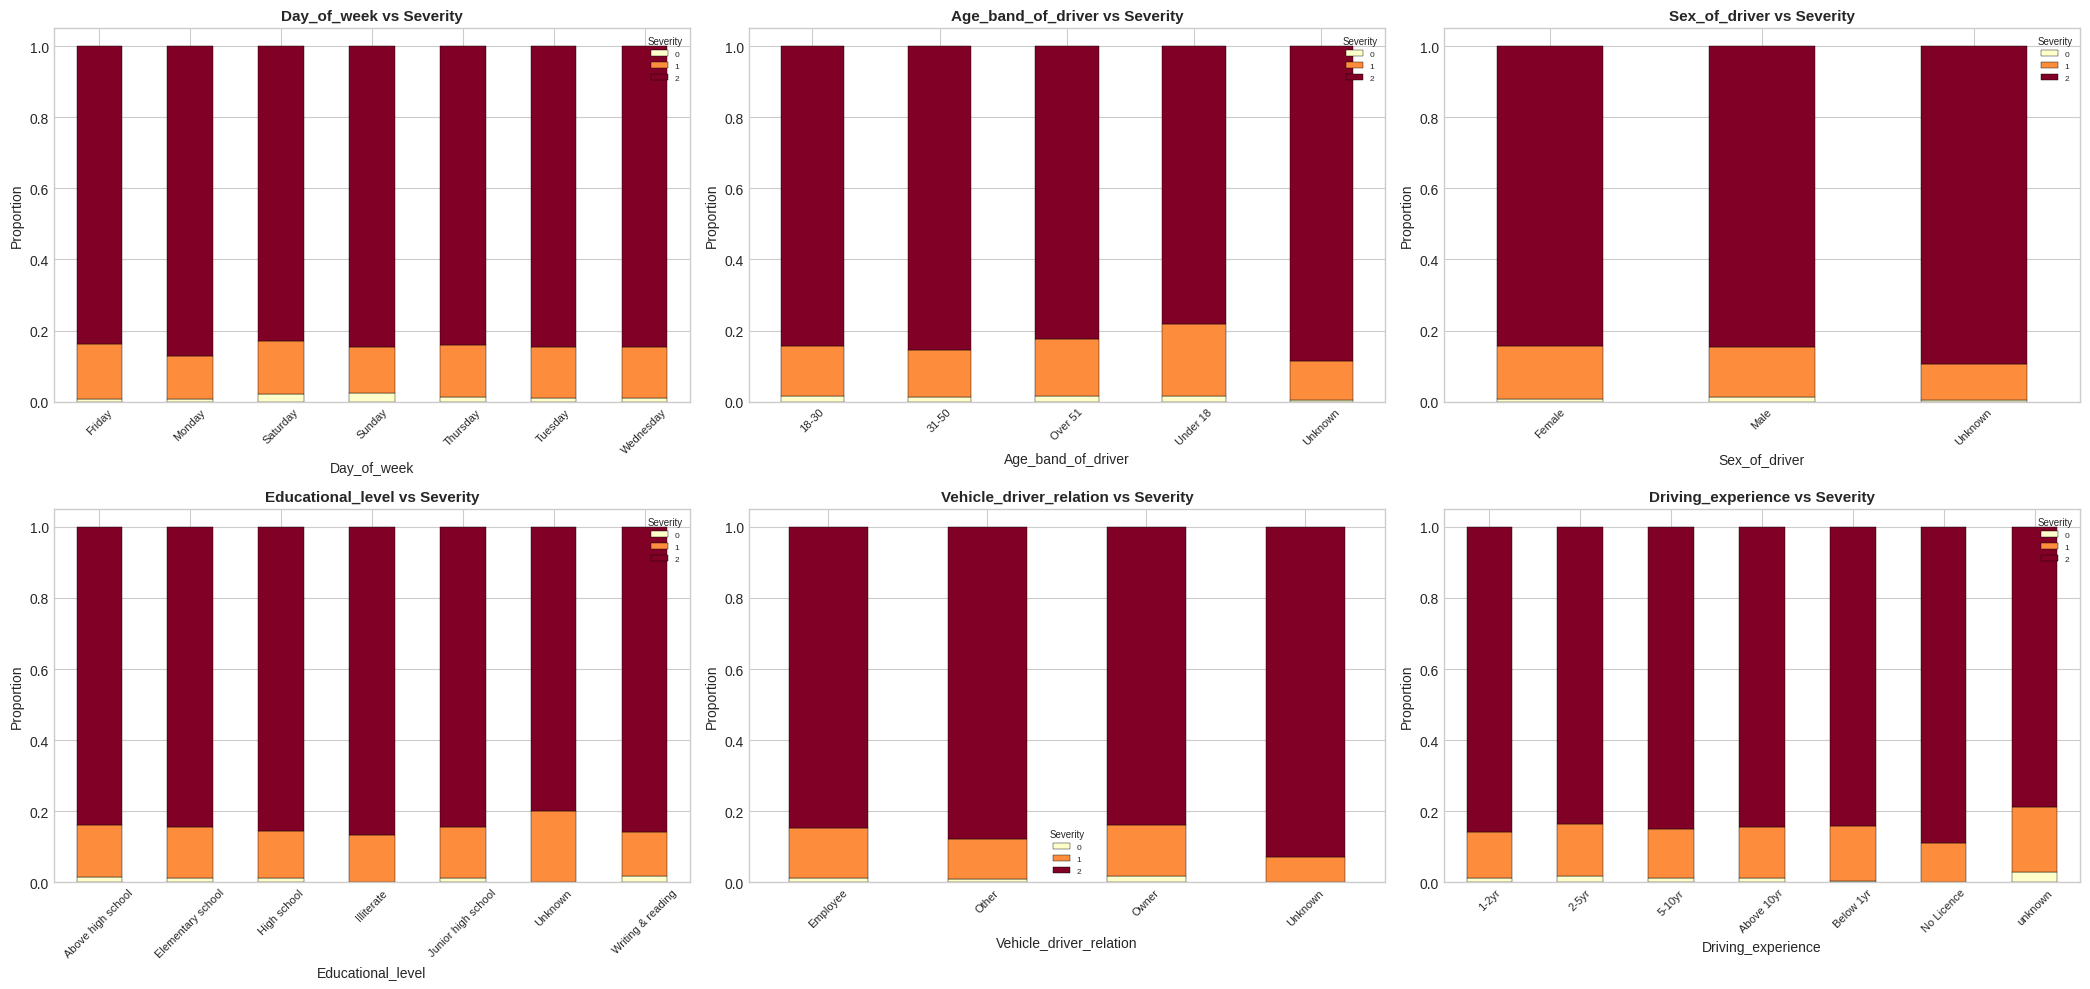

In [6]:
# === Categorical feature analysis (this dataset is heavily categorical) ===
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols: cat_cols.remove(target_col)
cat_cols = [c for c in cat_cols if df[c].nunique() <= 20 and 'id' not in c.lower()]
print(f"Categorical features ({len(cat_cols)}): {cat_cols[:10]}")

plot_cats = cat_cols[:6]
if len(plot_cats) > 0:
    n_cols_p = min(3, len(plot_cats))
    n_rows_p = (len(plot_cats) + n_cols_p - 1) // n_cols_p
    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(7 * n_cols_p, 5 * n_rows_p))
    if isinstance(axes, np.ndarray): axes = axes.flatten()
    else: axes = [axes]
    for i, col in enumerate(plot_cats):
        ct = pd.crosstab(df[col], df[target_col], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='YlOrRd', edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'{col} vs Severity', fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Proportion')
        axes[i].legend(title='Severity', fontsize=6, title_fontsize=7)
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout(); plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight'); plt.show()


Numeric features (2): ['Number_of_vehicles_involved', 'Number_of_casualties']


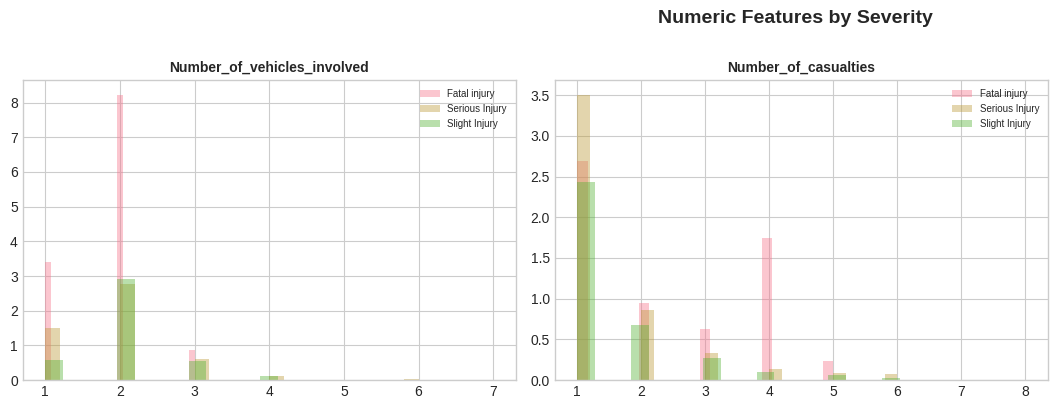

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(numeric_cols[numeric_cols.index(target_col)] if target_col in numeric_cols else None) if target_col in numeric_cols else None
numeric_cols = [c for c in numeric_cols if c != target_col and c.lower() not in ['id', 'index']]
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")

if len(numeric_cols) > 0:
    plot_cols = numeric_cols[:6]
    n_rows_p = (len(plot_cols) + 2) // 3
    fig, axes = plt.subplots(max(1, n_rows_p), 3, figsize=(16, 4 * max(1, n_rows_p)))
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
    for i, col in enumerate(plot_cols):
        for cls in sorted(df[target_col].unique()):
            subset = df[df[target_col] == cls][col].dropna()
            lbl = target_labels[cls] if cls < len(target_labels) else f'Class {cls}'
            if len(subset) > 0:
                axes[i].hist(subset, bins=25, alpha=0.4, label=lbl, density=True)
        axes[i].set_title(col, fontsize=10, fontweight='bold')
        axes[i].legend(fontsize=7)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Numeric Features by Severity', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('numeric_distributions.png', dpi=150, bbox_inches='tight'); plt.show()
else:
    print("Dataset is primarily categorical — numeric distributions skipped.")


## 4. Feature Engineering & Preprocessing

Road safety models benefit from:
- **Visibility risk score** — combining weather, light conditions, road surface
- **Vehicle vulnerability** — motorcycles/pedestrians vs cars/trucks
- **Time risk** — late night / early morning hours = higher fatality risk


In [8]:
df_model = df.copy()

# Replace '?' with NaN
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        n_q = (df_model[col] == '?').sum()
        if n_q > 0:
            df_model[col] = df_model[col].replace('?', np.nan)
            print(f"  Replaced {n_q} '?' in '{col}'")

# Drop ID columns
drop_cols = [c for c in df_model.columns if c.lower() in ['id', 'index', 'unnamed: 0']]
if drop_cols:
    print(f"Dropping: {drop_cols}")
    df_model.drop(columns=drop_cols, inplace=True)

# Encode categoricals
le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values
assert len(np.unique(y)) >= 2

null_counts = X.isnull().sum()
if null_counts.sum() > 0:
    print(f"Imputing {null_counts.sum()} missing values...")
    X = X.fillna(X.median())
print(f"\nFeature matrix: {X.shape}")
print(f"Target classes: {np.unique(y)} counts: {dict(zip(*np.unique(y, return_counts=True)))}")


  Encoded 'Time': 1074 classes
  Encoded 'Day_of_week': 7 classes
  Encoded 'Age_band_of_driver': 5 classes
  Encoded 'Sex_of_driver': 3 classes
  Encoded 'Educational_level': 8 classes
  Encoded 'Vehicle_driver_relation': 5 classes
  Encoded 'Driving_experience': 8 classes
  Encoded 'Type_of_vehicle': 18 classes
  Encoded 'Owner_of_vehicle': 5 classes
  Encoded 'Service_year_of_vehicle': 7 classes
  Encoded 'Defect_of_vehicle': 4 classes
  Encoded 'Area_accident_occured': 15 classes
  Encoded 'Lanes_or_Medians': 8 classes
  Encoded 'Road_allignment': 10 classes
  Encoded 'Types_of_Junction': 9 classes
  Encoded 'Road_surface_type': 6 classes
  Encoded 'Road_surface_conditions': 4 classes
  Encoded 'Light_conditions': 4 classes
  Encoded 'Weather_conditions': 9 classes
  Encoded 'Type_of_collision': 11 classes
  Encoded 'Vehicle_movement': 14 classes
  Encoded 'Casualty_class': 4 classes
  Encoded 'Sex_of_casualty': 3 classes
  Encoded 'Age_band_of_casualty': 6 classes
  Encoded 'Casua

In [9]:
feature_names = X.columns.tolist()
composites_added = []

# Number of vehicles/casualties interaction
vehicle_cols = [c for c in feature_names if 'vehicle' in c.lower() and 'number' in c.lower()]
casualty_cols = [c for c in feature_names if 'casualt' in c.lower() and 'number' in c.lower()]
if vehicle_cols and casualty_cols:
    X['casualties_per_vehicle'] = X[casualty_cols[0]] / (X[vehicle_cols[0]] + 1)
    composites_added.append('casualties_per_vehicle')
    print(f"Created 'casualties_per_vehicle'")

# Hour risk bucket (if hour/time column exists)
hour_cols = [c for c in feature_names if 'hour' in c.lower() or 'time' in c.lower()]
for hc in hour_cols:
    if X[hc].dtype in ['int64', 'float64'] and X[hc].max() <= 24:
        X['high_risk_hour'] = ((X[hc] >= 22) | (X[hc] <= 5)).astype(int)
        composites_added.append('high_risk_hour')
        print(f"Created 'high_risk_hour' from {hc}")
        break

# Age risk (young/elderly drivers)
age_cols = [c for c in feature_names if 'age' in c.lower() and 'driver' in c.lower()]
if not age_cols:
    age_cols = [c for c in feature_names if 'age' in c.lower() and 'vehicle' not in c.lower()]
for ac in age_cols:
    if X[ac].dtype in ['int64', 'float64']:
        X['age_risk'] = ((X[ac] < 25) | (X[ac] > 65)).astype(int)
        composites_added.append('age_risk')
        print(f"Created 'age_risk' from {ac}")
        break

if composites_added:
    print(f"\nTotal engineered: {len(composites_added)}")
else:
    print("\nNo composites created — using raw encoded features.")
print(f"Final feature count: {X.shape[1]}")


Created 'casualties_per_vehicle'
Created 'age_risk' from Age_band_of_driver

Total engineered: 2
Final feature count: 33


## 5. Model Training & Cross-Validation

In [10]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [11]:
n_classes = len(np.unique(y))
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42,
                                                multi_class='multinomial' if n_classes > 2 else 'auto'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42,
        eval_metric='mlogloss' if n_classes > 2 else 'logloss',
        use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_acc, fold_f1, fold_kappa = [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        fold_preds[val_idx] = y_pred
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='weighted')
        kappa = cohen_kappa_score(y_val, y_pred)
        fold_acc.append(acc); fold_f1.append(f1); fold_kappa.append(kappa)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1(w)={f1:.4f}  Kappa={kappa:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'accuracy_std': np.std(fold_acc),
        'f1_mean': np.mean(fold_f1), 'f1_std': np.std(fold_f1),
        'kappa_mean': np.mean(fold_kappa), 'kappa_std': np.std(fold_kappa),
        'time': elapsed, 'oof_preds': fold_preds}
    print(f"  -- Mean Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  Kappa: {np.mean(fold_kappa):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=0.8456  F1(w)=0.7748  Kappa=0.0000
  Fold 2: Acc=0.8458  F1(w)=0.7751  Kappa=0.0000
  Fold 3: Acc=0.8456  F1(w)=0.7748  Kappa=0.0000
  -- Mean Acc: 0.8456  F1: 0.7749  Kappa: 0.0000  Time: 83.47s

Training: Random Forest
  Fold 1: Acc=0.8495  F1(w)=0.7863  Kappa=0.0536
  Fold 2: Acc=0.8487  F1(w)=0.7831  Kappa=0.0372
  Fold 3: Acc=0.8490  F1(w)=0.7833  Kappa=0.0392
  -- Mean Acc: 0.8491  F1: 0.7842  Kappa: 0.0433  Time: 2.43s

Training: XGBoost
  Fold 1: Acc=0.8519  F1(w)=0.8062  Kappa=0.1545
  Fold 2: Acc=0.8555  F1(w)=0.8120  Kappa=0.1789
  Fold 3: Acc=0.8487  F1(w)=0.8028  Kappa=0.1410
  -- Mean Acc: 0.8521  F1: 0.8070  Kappa: 0.1581  Time: 1.48s

Training: LightGBM
  Fold 1: Acc=0.8553  F1(w)=0.8039  Kappa=0.1382
  Fold 2: Acc=0.8551  F1(w)=0.8019  Kappa=0.1271
  Fold 3: Acc=0.8521  F1(w)=0.7963  Kappa=0.1036
  -- Mean Acc: 0.8542  F1: 0.8007  Kappa: 0.1230  Time: 2.18s


## 6. Model Comparison & Selection

In [12]:
summary_rows = []
for mn, res in results.items():
    summary_rows.append({'Model': mn,
        'Accuracy': f"{res['accuracy_mean']:.4f} +/- {res['accuracy_std']:.4f}",
        'F1 (weighted)': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
        "Cohen's Kappa": f"{res['kappa_mean']:.4f} +/- {res['kappa_std']:.4f}",
        'Time': f"{res['time']:.2f}s", 'F1_val': res['f1_mean']})
summary_df = pd.DataFrame(summary_rows).sort_values('F1_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 100)
print(summary_df[['Model', 'Accuracy', 'F1 (weighted)', "Cohen's Kappa", 'Time']].to_string(index=False))
print("=" * 100)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model          Accuracy     F1 (weighted)     Cohen's Kappa   Time
            XGBoost 0.8521 +/- 0.0028 0.8070 +/- 0.0038 0.1581 +/- 0.0157  1.48s
           LightGBM 0.8542 +/- 0.0014 0.8007 +/- 0.0032 0.1230 +/- 0.0144  2.18s
      Random Forest 0.8491 +/- 0.0003 0.7842 +/- 0.0015 0.0433 +/- 0.0073  2.43s
Logistic Regression 0.8456 +/- 0.0001 0.7749 +/- 0.0002 0.0000 +/- 0.0000 83.47s

Best model: XGBoost


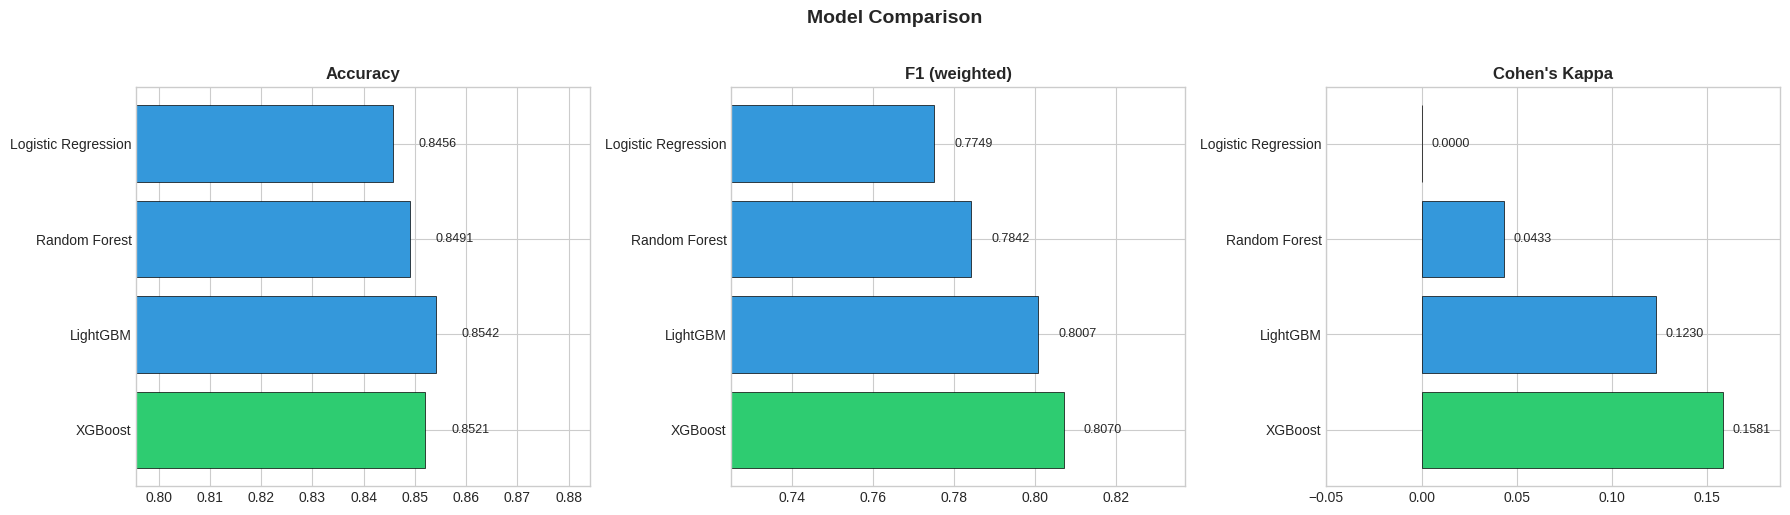

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['Model'] for _, r in summary_df.iterrows()]
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_names]
for ax, metric, title in zip(axes, ['accuracy_mean', 'f1_mean', 'kappa_mean'], ['Accuracy', 'F1 (weighted)', "Cohen's Kappa"]):
    vals = [results[m][metric] for m in model_names]
    ax.barh(model_names, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(min(vals) - 0.05, max(vals) + 0.03)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Error Analysis

For road safety:
- Predicting **Fatal as Slight** = under-response, potential death
- Predicting **Slight as Fatal** = over-response, but safer (acceptable trade-off)
- Adjacent errors (Serious↔Fatal) are less concerning than distant (Slight↔Fatal)


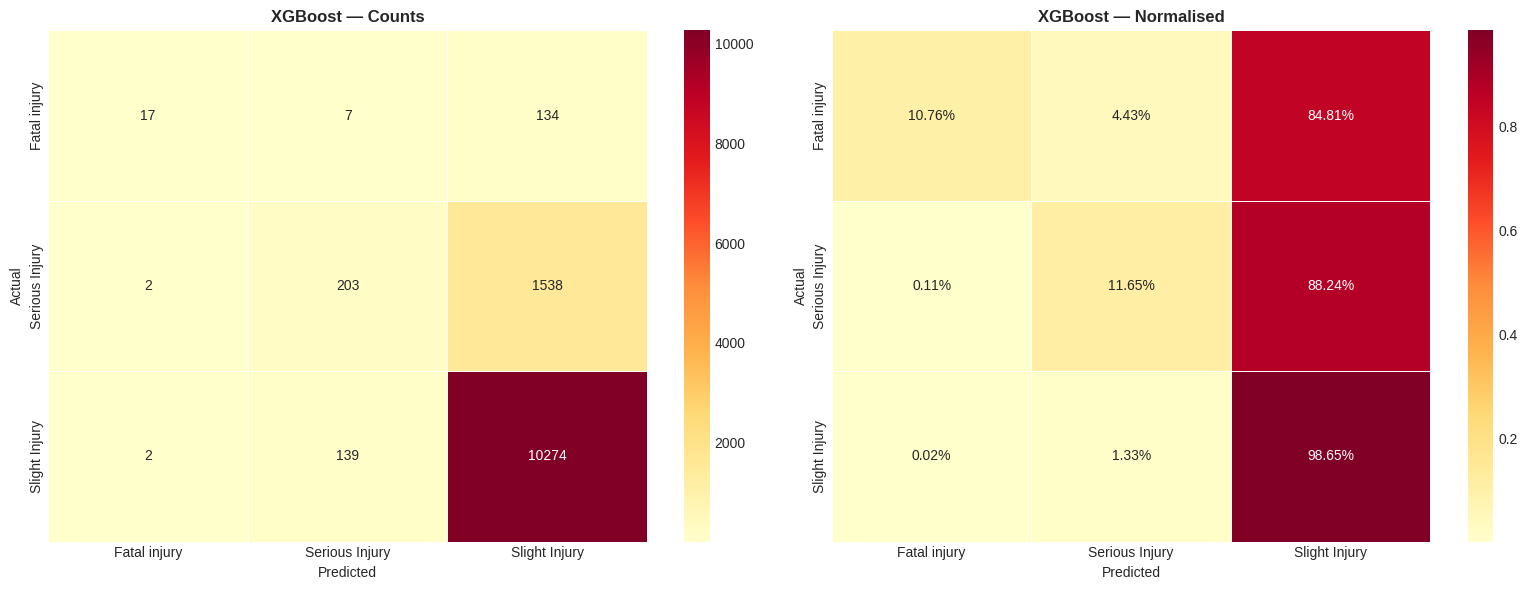


                precision    recall  f1-score   support

  Fatal injury       0.81      0.11      0.19       158
Serious Injury       0.58      0.12      0.19      1743
 Slight Injury       0.86      0.99      0.92     10415

      accuracy                           0.85     12316
     macro avg       0.75      0.40      0.43     12316
  weighted avg       0.82      0.85      0.81     12316



In [14]:
best_preds = results[best_model_name]['oof_preds']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', xticklabels=target_labels,
            yticklabels=target_labels, ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='YlOrRd', xticklabels=target_labels,
            yticklabels=target_labels, ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\n{classification_report(y, best_preds, target_names=target_labels)}")


## 8. Feature Importance & Policy Insights

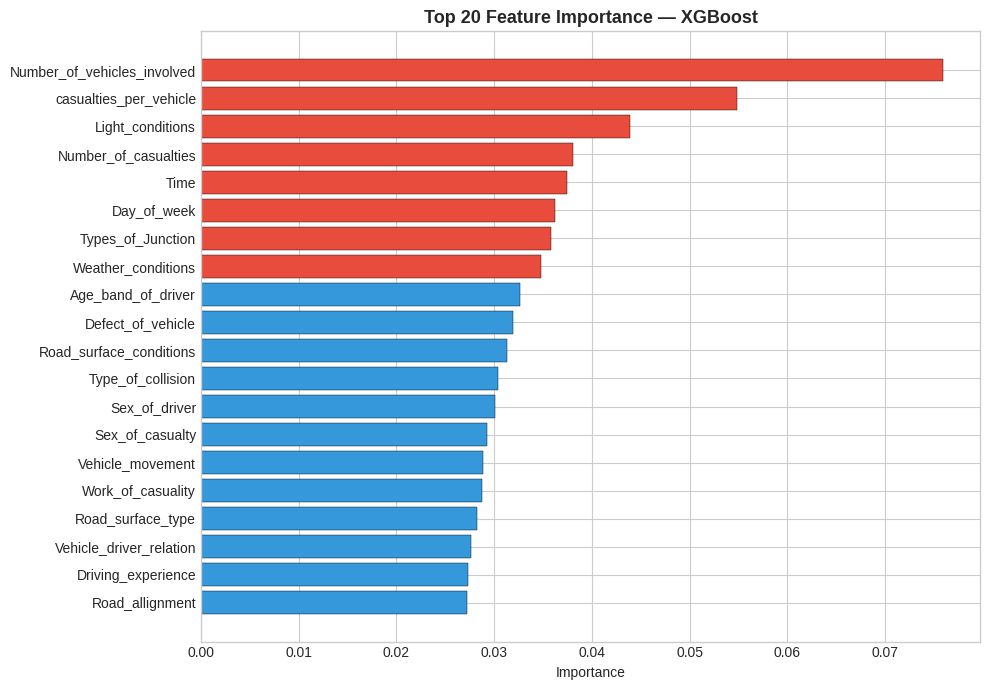

TOP 5 PREDICTIVE FEATURES
  Number_of_vehicles_involved          0.0759
  casualties_per_vehicle               0.0548
  Light_conditions                     0.0439
  Number_of_casualties                 0.0380
  Time                                 0.0374


In [15]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['f1_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    plot_imp = feat_imp.tail(20)
    fig, ax = plt.subplots(figsize=(10, max(6, len(plot_imp) * 0.35)))
    colors_imp = ['#e74c3c' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db' for imp in plot_imp['Importance']]
    ax.barh(plot_imp['Feature'], plot_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Top 20 Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 PREDICTIVE FEATURES")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:35s}  {row['Importance']:.4f}")


## 9. Deployment Readiness & Production Considerations

In [16]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  Accuracy:             {best_res['accuracy_mean']:.4f}")
print(f"  F1 (weighted):        {best_res['f1_mean']:.4f}")
print(f"  Cohen's Kappa:        {best_res['kappa_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  Target classes:       {n_classes}")
print(f"  CV strategy:          3-fold Stratified")
print("=" * 60)
checks = {
    'Accuracy > 0.50': best_res['accuracy_mean'] > 0.50,
    'F1 (weighted) > 0.45': best_res['f1_mean'] > 0.45,
    'Kappa > 0.20 (fair+)': best_res['kappa_mean'] > 0.20,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Feature importance available': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    XGBoost
  Accuracy:             0.8521
  F1 (weighted):        0.8070
  Cohen's Kappa:        0.1581
  Training time:        1.5s
  Feature count:        33
  Dataset rows:         12,316
  Target classes:       3
  CV strategy:          3-fold Stratified

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] Accuracy > 0.50
  [pass] F1 (weighted) > 0.45
  [FAIL] Kappa > 0.20 (fair+)
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Feature importance available
--------------------------------------------------
  SOME CHECKS FAILED


In [17]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: Police crash reports (WebCrash/CrashLink), road sensor network
   Ingestion: Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (road attributes, weather, vehicle registry)
   Schedule: Real-time scoring at incident report + daily batch analytics

2. MODEL SERVING
   Framework: MLflow on Databricks / Fabric ML
   Endpoint: Real-time (<1s per incident for dispatch triage)
   Batch: Weekly black spot analysis, monthly trend reporting
   Ensemble: Combine with BOM weather forecasts for proactive alerts

3. INTEGRATION POINTS
   Emergency dispatch: CAD system integration for triage
   Road authority: Black spot identification dashboard (Power BI)
   Policy: Crash cost estimation for infrastructure business cases
   Insurance: Actuarial risk modelling for motor vehicle premiums

4. SAFETY & GOVERNANCE
   Failsafe: Model failure -> standard dispatch protocol
   Override: Dispatchers always override model recommendations
   Audit: All predictions logged against actual outcomes (coronial data)
   Compliance: Privacy Act (crash data), Road Safety Act (state)
   Ethics: No demographic-based dispatch discrimination

5. MONITORING & RETRAINING
   Drift: PSI on crash characteristics quarterly
   Performance: F1 on coronial/hospital-confirmed severity annually
   Retraining: Annual with validated severity outcomes (12-month lag)
   Seasonal: Wet weather / holiday period model variants
   Events: Major event mode (concerts, sporting events, festivals)

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: Police crash reports (WebCrash/CrashLink), road sensor network
   Ingestion: Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (road attributes, weather, vehicle registry)
   Schedule: Real-time scoring at incident report + daily batch analytics

2. MODEL SERVING
   Framework: MLflow on Databricks / Fabric ML
   Endpoint: Real-time (<1s per incident for dispatch triage)
   Batch: Weekly black spot analysis, monthly trend reporting
   Ensemble: Combine with BOM weather forecasts for proactive alerts

3. INTEGRATION POINTS
   Emergency dispatch: CAD system integration for triage
   Road authority: Black spot identification dashboard (Power BI)
   Policy: Crash cost estimation for infrastructure business cases
   Insurance: Actuarial risk modelling for motor vehicle premiums

4. SAFETY & GOVERNANCE
   Failsafe: Model failure -> standard dispatch protocol
   Override: Dispatchers always ove